**Activar el DRIVE**

In [ ]:
try:
    from google.colab import drive

    drive.mount('/content/drive', force_remount=False)

    print("Google Drive montado correctamente")

except ModuleNotFoundError:

    print("Entorno local detectado (no Colab)")

**Leer los Archivos**

In [ ]:


import os
import pandas as pd
import matplotlib.pyplot as plt

"""
La variable ruta_archivos es donde esta el archivo
y archivos es una lista con los nombres de los archivos,
para que funcione bien los archivos deben venir el formato ".txt" y con numero secuanciado.
el rango esta definivo con base al numero de archivos que tengas:
ejemplo si tienes nombre1.txt ... mombre 10.txt, ences el rango seria
range(1,11) esto porque empieza en 1 y termina en 10. ya que no se lee el 11.

"""

ruta_archivos = "/content/drive/MyDrive/Doctorado/Proyecto_ICF/reduccion colorante con aunps papalo 24 01 2025-20260513T215036Z-3-001/"



def extraer_datos(nombre_archivo):
    with open(nombre_archivo, 'r', encoding='latin1') as f:
        lineas = f.readlines()

    inicio = None
    for i, linea in enumerate(lineas):
        if "Data Points" in linea:
            inicio = i + 2
            break
    if inicio is None:
        raise ValueError(f"No se encontró 'Data Points' en {nombre_archivo}")

    df = pd.read_csv(
        nombre_archivo,
        sep="\t",
        skiprows=inicio,
        names=["nm", "Abs"],
        encoding='latin1'
    )

    df = df.dropna()
    df["nm"] = pd.to_numeric(df["nm"], errors="coerce")
    df["Abs"] = pd.to_numeric(df["Abs"], errors="coerce")
    df = df.dropna()

    return df

archivos = [f"REDU COL. Ver +  H2O + NaBH4 + AuNPs PAPALO  {i}.TXT" for i in range(1,5)]
archivos = [ruta_archivos + f for f in archivos]

# Verificar existencia
for a in archivos:
    if not os.path.exists(a):
        print(f"⚠️ Archivo no encontrado: {a}")

**Graficar**

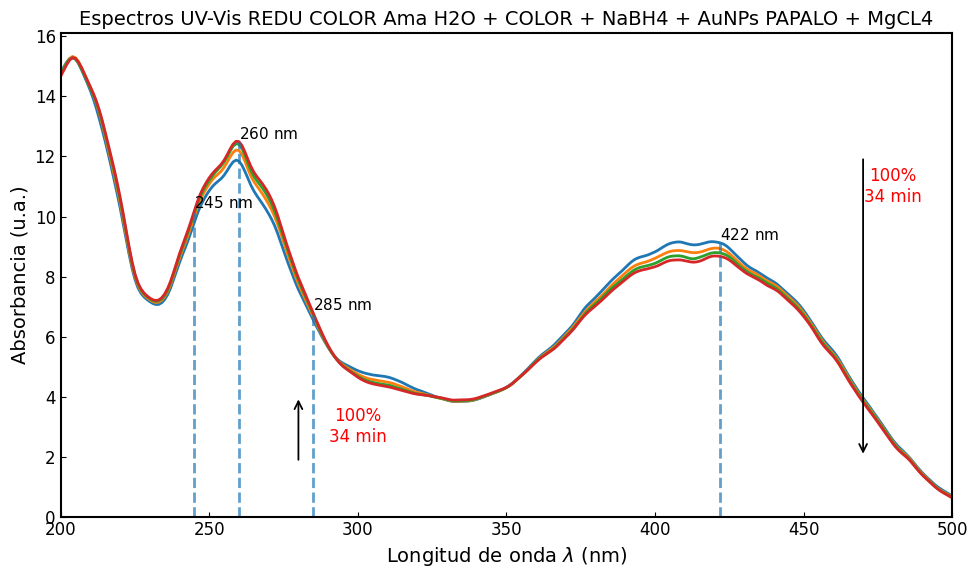


 TABLA 1 (Abs a 410 nm):
   X   Abs_410
0  0  9.115714
1  2  8.844143
2  4  8.653274
3  6  8.528641


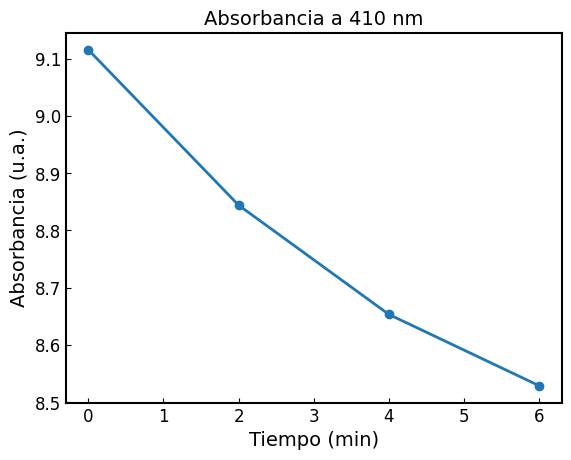


 TABLA 2 (Normalizado):
   X  Abs_norm
0  0  1.000000
1  2  0.970208
2  4  0.949270
3  6  0.935598


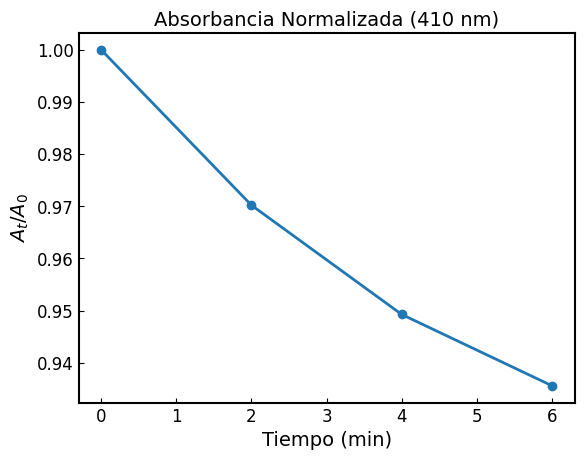


TABLA 3 (Log):
   X  ln(Abs_norm)
0  0      0.000000
1  2     -0.030244
2  4     -0.052062
3  6     -0.066570


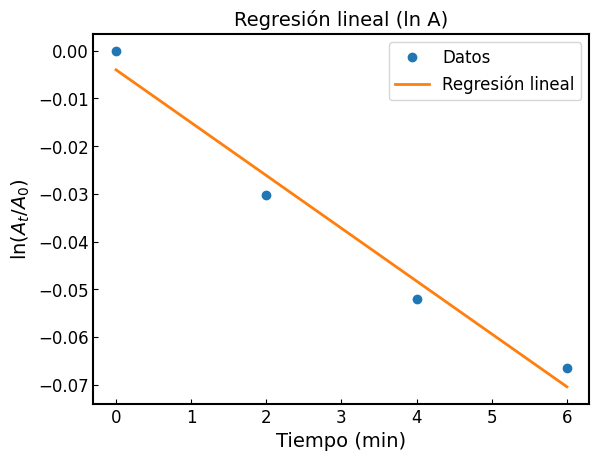


Pendiente (slope): -0.011076
Error estándar pendiente: 0.001245

IC 95% pendiente:
[-0.016432, -0.005721]

Intercepto: -0.003990
Error estándar intercepto: 0.004657

R²: 0.9754

Constante de velocidad k: 0.011076

IC 95% para k:
[0.005721, 0.016432]

 Eficiencia a 410 nm: 6.44%

 k′ = k/m = 11245.015288 (unidades dependen de k y m)
 Qt = 387.408645 g/g

ΔG‡ = 94.3311 kJ/mol
Error estándar ΔG‡ = ±0.2786 kJ/mol

IC 95% ΔG‡:
[93.1326, 95.5297] kJ/mol

 TON y TOF
Masa degradada del contaminante = 0.000042 g
Moles de contaminante degradado = 6.308481e-08 mol
Moles de catalizador = 5.000762e-09 mol

 TON = 12.615042
 TOF = 2.102507 min^-1


In [ ]:
plt.figure(figsize=(10, 6))

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.5,
    "lines.linewidth": 2,
    "xtick.direction": "in",
    "ytick.direction": "in"
})

# =====================================================
# DATOS EXPERIMENTALES (MODIFICAR SEGÚN TU EXPERIMENTO)
# =====================================================

m = 0.000000985   # masa del catalizador (g)
M = 0.00065    # masa del contaminante orgánico (g)

masa_molar_catalizador = 196.97   # g/mol (ejemplo: Ag = 107.87, Au = 196.97)
masa_molar_contaminante = 663.575  # g/mol (ejemplo: 4-NF ≈ 139.11 g/mol)

T = 298.15  # temperatura en K

# Constantes físicas
kb = 1.380649e-23   # Constante de Boltzmann (J/K)
h = 6.62607015e-34  # Constante de Planck (J·s)
R = 8.314           # Constante de los gases (J/mol·K)

####### Datos para las graficas #################################

####### lineas punteadas de UV_VIS ##############################
valores_primera = [ 422 ]   # respecto a la primera curva
valores_ultima = [245, 260, 285]    # respecto a la última curva

####### longitud de onda (nm) en la que se realizaran los estadisticos########

lambda_objetivo = 410   # CAMBIA AQUÍ la longitud de onda (nm)

##############################################################################
### Grafica de UV_VIS
##############################################################################

y_primera = {}
y_ultima = {}

for i, archivo in enumerate(archivos):
    df = extraer_datos(archivo)

    plt.plot(
        df["nm"],
        df["Abs"],
        label=rf"$\mathrm{{Lluvia\ 4NF}}_{{{i+1}}}$"
   )


    if i == 0:
        for x_nm in valores_primera:
            y_nm = df.loc[(df["nm"] - x_nm).abs().idxmin(), "Abs"]
            y_primera[x_nm] = y_nm


    if i == len(archivos) - 1:
        for x_nm in valores_ultima:
            y_nm = df.loc[(df["nm"] - x_nm).abs().idxmin(), "Abs"]
            y_ultima[x_nm] = y_nm



for x_nm, y_nm in y_primera.items():
    plt.vlines(x_nm, 0, y_nm, linestyles='dashed', alpha=0.7)
    plt.text(x_nm, y_nm,
             rf'${x_nm}\ \mathrm{{nm}}$',
             fontsize=11,
             ha='left',
             va='bottom')

for x_nm, y_nm in y_ultima.items():
    plt.vlines(x_nm, 0, y_nm, linestyles='dashed', alpha=0.7)
    plt.text(x_nm, y_nm,
             rf'${x_nm}\ \mathrm{{nm}}$',
             fontsize=11,
             ha='left',
             va='bottom')

########################################################################
##LINEAS Y FLECHAS
########################################################################
# Líneas verticales
#plt.plot([200, 250], [0, 15], linestyle='dashed' , alpha=0.7)

# Flecha hacia abajo
plt.annotate(
    '',
    xy=(470, 2),      # punto final (abajo)
    xytext=(470, 12),  # punto inicial (arriba)
    arrowprops=dict(arrowstyle='->', linewidth=1.3, color='black')
)
# etiqueta arriba de la flecha
plt.text(480, 11, "100%\n34 min", color='red', fontsize=12, ha='center',
         va='center', linespacing=1.2 )

# Flecha hacia arriba
plt.annotate(
    '',
    xy=(280, 4),      # punto final (abajo)
    xytext=(280, 1.8),  # punto inicial (arriba)
    arrowprops=dict(arrowstyle='->', linewidth=1.3, color='black')
)
# etiqueta arriba de la flecha
plt.text(300, 3, "100%\n34 min", color='red', fontsize=12, ha='center',
         va='center', linespacing=1.2 )

########################################################################

#plt.grid(alpha=0.3) #mayado
#plt.legend()## esto es para la etiquetas de cada linea
plt.xlabel(r'Longitud de onda $\lambda$ (nm)', fontsize=14)
plt.ylabel(r'Absorbancia (u.a.)', fontsize=14)
plt.title(r'Espectros UV-Vis REDU COLOR Ama H2O + COLOR + NaBH4 + AuNPs PAPALO + MgCL4', fontsize=14)


# Límites de los ejes
plt.xlim(200, 500)
plt.ylim(0, None)


plt.tight_layout()
plt.savefig(ruta_archivos + "uv_vis.pdf", dpi=300, bbox_inches='tight')
plt.show()



##########################################################################
# Analisis de datos
##########################################################################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# 1. EXTRAER Abs a λ variable
# =========================

abs_lambda = []

for archivo in archivos:
    df = extraer_datos(archivo)

    fila = df.iloc[(df["nm"] - lambda_objetivo).abs().argsort()[:1]]
    abs_lambda.append(fila["Abs"].values[0])

x = np.arange(0, 2 * len(abs_lambda), 2)

tabla1 = pd.DataFrame({
    "X": x,
    f"Abs_{lambda_objetivo}": abs_lambda
})

print(f"\n TABLA 1 (Abs a {lambda_objetivo} nm):")
print(tabla1)

plt.figure()
plt.plot(x, abs_lambda, marker='o')
plt.title(f"Absorbancia a {lambda_objetivo} nm")
plt.xlabel(r'Tiempo (min)', fontsize=14)
plt.ylabel(r'Absorbancia (u.a.)')
#plt.grid()
plt.savefig(ruta_archivos + "abs.pdf", dpi=300, bbox_inches='tight')
plt.show()

# =========================
# 2. NORMALIZACIÓN
# =========================

abs0 = abs_lambda[0]
abs_norm = [a / abs0 for a in abs_lambda]

tabla2 = pd.DataFrame({
    "X": x,
    "Abs_norm": abs_norm
})

print("\n TABLA 2 (Normalizado):")
print(tabla2)

plt.figure()
plt.plot(x, abs_norm, marker='o')
plt.title(f"Absorbancia Normalizada ({lambda_objetivo} nm)")
plt.xlabel(r'Tiempo (min)')
plt.ylabel(r"$A_t$/$A_0$")
#plt.grid()
plt.savefig(ruta_archivos + "normalizada.pdf", dpi=300, bbox_inches='tight')
plt.show()




from scipy.stats import linregress, t

# =========================
# 3. LOG + REGRESIÓN LINEAL
# =========================

# Para cinética de pseudo-primer orden:
# ln(Ct/C0) = -kt
# Donde:
# Ct es la concentracion respecto al tiempo
# C0 es la concentracion inicial
# K es la velocidad de reacción

log_abs = np.log(abs_norm)

# =========================
# REGRESIÓN LINEAL
# =========================

resultado = linregress(x, log_abs)

pendiente = resultado.slope
intercepto = resultado.intercept
r_value = resultado.rvalue
stderr_pendiente = resultado.stderr
stderr_intercepto = resultado.intercept_stderr

k = -pendiente

y_fit = pendiente * x + intercepto

r2 = r_value**2

# =========================
# INTERVALO DE CONFIANZA 95%
# =========================

n = len(x)
alpha = 0.05

t_crit = t.ppf(1 - alpha/2, df=n-2)

ic_pendiente = (
    pendiente - t_crit * stderr_pendiente,
    pendiente + t_crit * stderr_pendiente
)

ic_intercepto = (
    intercepto - t_crit * stderr_intercepto,
    intercepto + t_crit * stderr_intercepto
)

ic_k = (
    -ic_pendiente[1],
    -ic_pendiente[0]
)

# =========================
# TABLA
# =========================

tabla3 = pd.DataFrame({
    "X": x,
    "ln(Abs_norm)": log_abs
})

print("\nTABLA 3 (Log):")
print(tabla3)

# =========================
# GRÁFICA
# =========================

plt.figure()

plt.plot(x, log_abs, 'o', label="Datos")
plt.plot(x, y_fit, '-', label="Regresión lineal")

plt.title("Regresión lineal (ln A)")
plt.xlabel(r'Tiempo (min)')
plt.ylabel(r"ln($A_t/A_0$)")

plt.legend()
# plt.grid()
plt.savefig(ruta_archivos + "regrecion.pdf", dpi=300, bbox_inches='tight')
plt.show()

# =========================
# RESULTADOS
# =========================

print(f"\nPendiente (slope): {pendiente:.6f}")
print(f"Error estándar pendiente: {stderr_pendiente:.6f}")

print(f"\nIC 95% pendiente:")
print(f"[{ic_pendiente[0]:.6f}, {ic_pendiente[1]:.6f}]")

print(f"\nIntercepto: {intercepto:.6f}")
print(f"Error estándar intercepto: {stderr_intercepto:.6f}")

print(f"\nR²: {r2:.4f}")

print(f"\nConstante de velocidad k: {k:.6f}")

print(f"\nIC 95% para k:")
print(f"[{ic_k[0]:.6f}, {ic_k[1]:.6f}]")

# =========================
# 4. EFICIENCIA
# =========================

#Eficiencia = C0-Cf/C0 * 100
# Donde:
# Cf es la concentracion final
# C0 es la concentracion inicial

abs_final = abs_lambda[-1]

eficiencia = ((abs0 - abs_final) / abs0) * 100

print(f"\n Eficiencia a {lambda_objetivo} nm: {eficiencia:.2f}%")


# =========================
# 5. Parametro de actividad (k ′)
# =========================

#parametro de actividad
# k ′ = k / m
# Donde:
# m es la masa del catalizador
# k la velocidad de la reacción

k_prima = k / m

print(f"\n k′ = k/m = {k_prima:.6f} (unidades dependen de k y m)")

# =========================
# 6. Capacidad de reducción (Qt)
# =========================

# Qt = (C0 - Cf) × M / m
# Donde:
# m es la masa del catalizador
# M es la masa del contaminante
# Cf es la concentracion final
# C0 es la concentracion inicial

Qt = (abs0 - abs_final) * M / m

print(f" Qt = {Qt:.6f} g/g")

# =========================
# 7. ΔG‡ (Energía libre de activación)
# =========================

#    Ecuación de Eyring
#    ΔG‡ = RT ln(kB*T / h*k)
# Donde:
# T es la temperatura en K
# R es la constante de los gases
# Kb es la Constante de Boltzmann
# K es la velocidad de reaccion
# h es la constante de Planck



# Convertir k de min^-1 a s^-1
k_seg = k / 60

# Error estándar de k
stderr_k = stderr_pendiente / 60

# =========================
# ΔG‡
# =========================

delta_G = R * T * np.log((kb * T) / (h * k_seg))

# convertir a kJ/mol
delta_G_kJ = delta_G / 1000

# =========================
# ERROR ESTÁNDAR
# =========================

error_delta_G = (R * T * (stderr_k / k_seg)) / 1000

# =========================
# INTERVALO DE CONFIANZA 95%
# =========================

ic_delta_G = (
    delta_G_kJ - t_crit * error_delta_G,
    delta_G_kJ + t_crit * error_delta_G
)

# =========================
# RESULTADOS
# =========================

print(f"\nΔG‡ = {delta_G_kJ:.4f} kJ/mol")

print(f"Error estándar ΔG‡ = ±{error_delta_G:.4f} kJ/mol")

print("\nIC 95% ΔG‡:")
print(f"[{ic_delta_G[0]:.4f}, {ic_delta_G[1]:.4f}] kJ/mol")

# =========================
# 8. Número de recambio (TON)
# y Frecuencia de recambio (TOF)
# =========================

# TON = moles_contaminante / moles_catalizador
# TOF = TON/tiempo_reaccion

tiempo_reaccion_min = x[-1]

fraccion_degradada = eficiencia / 100

# =========================
# CÁLCULOS
# =========================


masa_contaminante_degradada = M * fraccion_degradada

moles_contaminante = (
    masa_contaminante_degradada / masa_molar_contaminante
)


moles_catalizador = m / masa_molar_catalizador


TON = moles_contaminante / moles_catalizador


TOF = TON / tiempo_reaccion_min

# =========================
# RESULTADOS
# =========================

print("\n=========================")
print(" TON y TOF")
print("=========================")

print(f"Masa degradada del contaminante = {masa_contaminante_degradada:.6f} g")
print(f"Moles de contaminante degradado = {moles_contaminante:.6e} mol")
print(f"Moles de catalizador = {moles_catalizador:.6e} mol")

print(f"\n TON = {TON:.6f}")
print(f" TOF = {TOF:.6f} min^-1")




TABLA DE RESIDUOS:
   Tiempo  Valor experimental  Valor ajustado   Residuo
0       0            0.000000       -0.003990  0.003990
1       2           -0.030244       -0.026143 -0.004102
2       4           -0.052062       -0.048295 -0.003767
3       6           -0.066570       -0.070448  0.003878


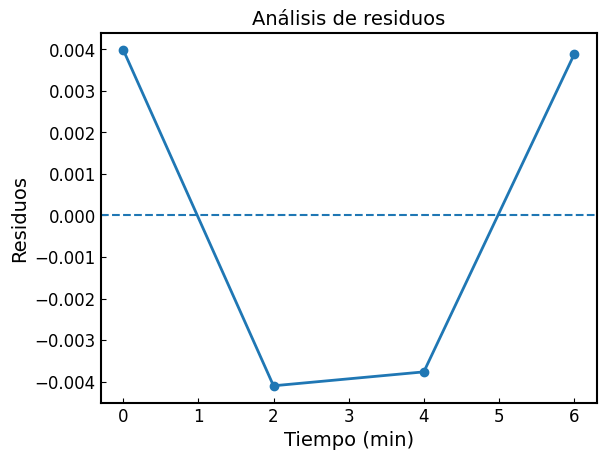

In [ ]:
# =========================
# VALIDACIÓN MDEIANTE
# RESIDUOS DE LA REGRESIÓN
# =========================

# Residuo:
# ri = yi - ŷi
#
# Donde:
# ri  = residuo del punto i
# yi  = valor experimental
# ŷi  = valor calculado por la recta
#
# Si:
# ri > 0  → el punto está arriba de la recta
# ri < 0  → el punto está debajo de la recta


residuos = log_abs - y_fit

tabla_residuos = pd.DataFrame({
    "Tiempo": x,
    "Valor experimental": log_abs,
    "Valor ajustado": y_fit,
    "Residuo": residuos
})

print("\nTABLA DE RESIDUOS:")
print(tabla_residuos)

# =========================
# GRÁFICA DE RESIDUOS
# =========================

plt.figure()

# Línea horizontal en cero
plt.axhline(0,
            linestyle='--',
            linewidth=1.5)

# Residuos
plt.plot(x,
         residuos,
         'o-')

plt.xlabel(r'Tiempo (min)')
plt.ylabel(r'Residuos')

plt.title('Análisis de residuos')

#plt.grid()
plt.savefig(ruta_archivos + "residuos.pdf", dpi=300, bbox_inches='tight')
plt.show()